In [6]:
import os

os.listdir('/content')

['.config', 'LC_loans_granting_model_dataset.zip', 'sample_data']

In [7]:
import zipfile
import os

zip_file = "LC_loans_granting_model_dataset.zip"

with zipfile.ZipFile(f'/content/{zip_file}', 'r') as z:
    z.extractall('/content')

os.listdir('/content')

['.config',
 'LC_loans_granting_model_dataset.zip',
 'LC_loans_granting_model_dataset.csv',
 'sample_data']

In [34]:
import pandas as pd

df = pd.read_csv(
    '/content/LC_loans_granting_model_dataset.csv',
    low_memory=False
)

print(df.shape)
df.head()

(1347681, 15)


,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,title,desc
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0,Debt consolidation,NaN
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0,Business,NaN
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0,NaN,NaN
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,174xx,0,Major purchase,NaN
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,300xx,0,Debt consolidation,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1347681 entries, 0 to 1347680
Data columns (total 15 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1347681 non-null  int64  
 1   issue_d           1347681 non-null  object 
 2   revenue           1347681 non-null  float64
 3   dti_n             1347681 non-null  float64
 4   loan_amnt         1347681 non-null  int64  
 5   fico_n            1347681 non-null  float64
 6   experience_c      1347681 non-null  int64  
 7   emp_length        1347681 non-null  object 
 8   purpose           1347681 non-null  object 
 9   home_ownership_n  1347681 non-null  object 
 10  addr_state        1347681 non-null  object 
 11  zip_code          1347680 non-null  object 
 12  Default           1347681 non-null  int64  
 13  title             1331024 non-null  object 
 14  desc              119099 non-null   object 
dtypes: float64(3), int64(4), object(8)
memory usage: 

In [10]:
print("중복 id 개수:", df['id'].duplicated().sum())


중복 id 개수: 0


In [11]:
missing = df.isnull().sum()

missing_rate = (
    missing / len(df) * 100
).sort_values(ascending=False)

pd.DataFrame({
    "missing_count": missing,
    "missing_rate(%)": missing_rate
})

,missing_count,missing_rate(%)
Default,0,0.000000
addr_state,0,0.000000
desc,1228582,91.162671
dti_n,0,0.000000
emp_length,0,0.000000
experience_c,0,0.000000
fico_n,0,0.000000
home_ownership_n,0,0.000000
id,0,0.000000
issue_d,0,0.000000


In [12]:
from sqlalchemy import create_engine

# SQLite DB 저장
engine = create_engine(
    "sqlite:///credit_risk.db"
)

df.to_sql(
    "loans",
    engine,
    if_exists="replace",
    index=False
)

print("SQLite 저장 완료")


SQLite 저장 완료


In [13]:
import pandas as pd

# 저장된 데이터 조회 테스트
pd.read_sql(
    """
    SELECT *
    FROM loans
    LIMIT 5;
    """,
    engine
)

,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,title,desc
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0,Debt consolidation,None
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0,Business,None
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0,None,None
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,174xx,0,Major purchase,None
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,300xx,0,Debt consolidation,None


In [14]:
#FICO 점수별 고객 특성 및 부도율 분석
fico_result = pd.read_sql(
    """
    WITH fico_grouped AS (
        SELECT
            CASE
                WHEN fico_n < 580 THEN 'Poor'
                WHEN fico_n < 670 THEN 'Fair'
                WHEN fico_n < 740 THEN 'Good'
                WHEN fico_n < 800 THEN 'Very Good'
                ELSE 'Exceptional'
            END AS fico_group,

            revenue,
            loan_amnt,
            "Default"

        FROM loans
    )

    SELECT
        fico_group,
        COUNT(*) AS customer_count,
        ROUND(AVG(revenue), 0) AS avg_income,
        ROUND(AVG(loan_amnt), 0) AS avg_loan_amount,
        ROUND(AVG("Default") * 100, 2) AS default_rate

    FROM fico_grouped

    GROUP BY fico_group

    ORDER BY default_rate DESC;
    """,
    engine
)

fico_result

,fico_group,customer_count,avg_income,avg_loan_amount,default_rate
0,Fair,238506,70388.0,12606.0,26.30
1,Good,963883,77672.0,14715.0,19.97
2,Very Good,129847,85622.0,15321.0,10.04
3,Exceptional,15445,96948.0,15404.0,6.41


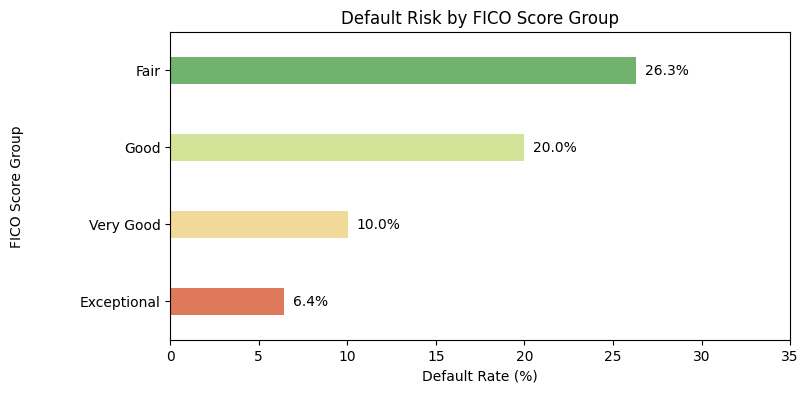

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

fico_plot = fico_result.sort_values(
    "default_rate",
    ascending=False
)

plt.figure(figsize=(8,4))

ax = sns.barplot(
    data=fico_plot,
    x="default_rate",
    y="fico_group",
    hue="fico_group",
    palette="RdYlGn_r",
    dodge=False,
    legend=False,
    width=0.35
)

for i, v in enumerate(fico_plot["default_rate"]):
    ax.text(
        v + 0.5,
        i,
        f"{v:.1f}%",
        va="center"
    )

ax.set_title("Default Risk by FICO Score Group")
ax.set_xlabel("Default Rate (%)")
ax.set_ylabel("FICO Score Group", labelpad=40)

ax.set_xlim(0, 35)

plt.savefig(
    "fico_default_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
dti_result = pd.read_sql(
    """
    WITH dti_grouped AS (
        SELECT
            CASE
                WHEN dti_n < 10 THEN 'Low'
                WHEN dti_n < 20 THEN 'Medium'
                WHEN dti_n < 30 THEN 'High'
                ELSE 'Very High'
            END AS dti_group,

            revenue,
            loan_amnt,
            "Default"

        FROM loans
    )

    SELECT
        dti_group,
        COUNT(*) AS customer_count,
        ROUND(AVG(revenue), 0) AS avg_income,
        ROUND(AVG(loan_amnt), 0) AS avg_loan_amount,
        ROUND(AVG("Default") * 100, 2) AS default_rate

    FROM dti_grouped

    GROUP BY dti_group

    ORDER BY
        CASE dti_group
            WHEN 'Low' THEN 1
            WHEN 'Medium' THEN 2
            WHEN 'High' THEN 3
            WHEN 'Very High' THEN 4
        END;
    """,
    engine
)

dti_result

,dti_group,customer_count,avg_income,avg_loan_amount,default_rate
0,Low,245174,95191.0,13507.0,14.84
1,Medium,563230,79805.0,14607.0,17.85
2,High,410172,67973.0,14713.0,23.07
3,Very High,129105,62758.0,14286.0,29.20


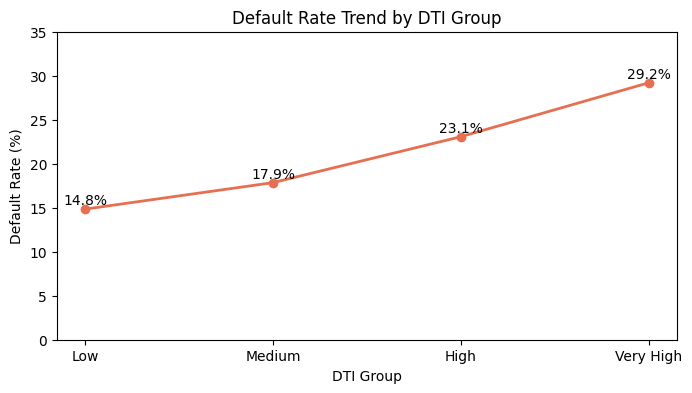

In [31]:
plt.figure(figsize=(8,4))

plt.plot(
    dti_result["dti_group"],
    dti_result["default_rate"],
    marker="o",
    linewidth=2,
    color="#E76F51"
)

for x, y in zip(
    dti_result["dti_group"],
    dti_result["default_rate"]
):
    plt.text(
        x,
        y+0.5,
        f"{y:.1f}%",
        ha="center"
    )

plt.title("Default Rate Trend by DTI Group")
plt.xlabel("DTI Group")
plt.ylabel("Default Rate (%)")

plt.ylim(0,35)

plt.savefig(
    "dti_default_rate.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [19]:
purpose_result = pd.read_sql(
    """
    SELECT
        purpose,
        COUNT(*) AS customer_count,
        ROUND(AVG(revenue), 0) AS avg_income,
        ROUND(AVG(loan_amnt), 0) AS avg_loan_amount,
        ROUND(AVG("Default") * 100, 2) AS default_rate

    FROM loans

    GROUP BY purpose

    ORDER BY default_rate DESC;
    """,
    engine
)

purpose_result

,purpose,customer_count,avg_income,avg_loan_amount,default_rate
0,small_business,15575,92454.0,15632.0,29.86
1,renewable_energy,936,74787.0,10004.0,23.72
2,moving,9520,70368.0,7853.0,23.41
3,house,7294,84297.0,15354.0,21.91
4,medical,15606,74756.0,8990.0,21.84
5,debt_consolidation,781206,76144.0,15224.0,21.15
6,other,78263,72713.0,9812.0,21.08
7,educational,423,51264.0,6616.0,20.80
8,vacation,9083,70471.0,6189.0,19.19
9,major_purchase,29543,79315.0,11818.0,18.60


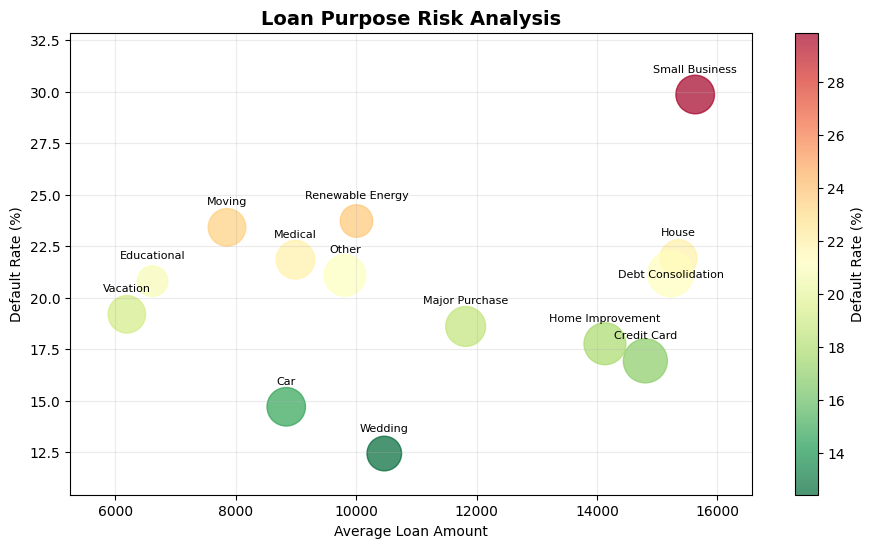

In [33]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = purpose_result.copy()

plot_data["purpose_label"] = (
    plot_data["purpose"]
    .str.replace("_", " ")
    .str.title()
)

plt.figure(figsize=(11,6))

sizes = np.log1p(
    plot_data["customer_count"]
) * 80


scatter = plt.scatter(
    plot_data["avg_loan_amount"],
    plot_data["default_rate"],
    s=sizes,
    c=plot_data["default_rate"],
    cmap="RdYlGn_r",
    alpha=0.7
)


for _, row in plot_data.iterrows():

    if row["purpose"] == "debt_consolidation":
        plt.text(
            row["avg_loan_amount"],
            row["default_rate"],
            row["purpose_label"],
            fontsize=8,
            ha="center",
            va="center"
        )

    else:
        plt.text(
            row["avg_loan_amount"],
            row["default_rate"] + 1.0,
            row["purpose_label"],
            fontsize=8,
            ha="center",
            va="bottom"
        )


plt.colorbar(
    scatter,
    label="Default Rate (%)"
)

plt.title(
    "Loan Purpose Risk Analysis",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average Loan Amount")
plt.ylabel("Default Rate (%)")

plt.margins(x=0.10)

plt.ylim(
    plot_data["default_rate"].min() - 2,
    plot_data["default_rate"].max() + 3
)

plt.grid(alpha=0.25)

plt.savefig(
    "loan_purpose_risk_analysis.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [25]:
purpose_result["purpose_label"] = (
    purpose_result["purpose"]
    .str.replace("_", " ")
    .str.title()
)


# FICO, DTI, Purpose 최고 부도율 그룹 요약

summary_result = pd.DataFrame({
    "분석 기준": [
        "FICO Score",
        "DTI",
        "Loan Purpose"
    ],
    "위험 구간": [
        fico_result.loc[fico_result["default_rate"].idxmax(), "fico_group"],
        dti_result.loc[dti_result["default_rate"].idxmax(), "dti_group"],
        purpose_result.loc[purpose_result["default_rate"].idxmax(), "purpose_label"]
    ],
    "부도율(%)": [
        fico_result["default_rate"].max(),
        dti_result["default_rate"].max(),
        purpose_result["default_rate"].max()
    ]
})

summary_result

,분석 기준,위험 구간,부도율(%)
0,FICO Score,Fair,26.30
1,DTI,Very High,29.20
2,Loan Purpose,Small Business,29.86
